The implementation of **DDPG (Deep Deterministic Policy Gradient)** algorithm.

Article Name: **Continuous Control with Deep Reinforcement Learning**

link: https://arxiv.org/abs/1509.02971

In [13]:
import os

dirs = [
    "td3_benchmark/configs",
    "td3_benchmark/src/agents",
    "td3_benchmark/src/models",
    "td3_benchmark/src/buffers",
    "td3_benchmark/src/utils",
    "td3_benchmark/tests"
]

for d in dirs:
    os.makedirs(d, exist_ok=True)
    with open(os.path.join(d, "__init__.py"), "w") as f:
        pass

فایل‌ها و پوشه‌ها با موفقیت ساخته شدند.


In [14]:
!pip install swig -q
!pip install "gymnasium[box2d]" -q

In [15]:
%%writefile td3_benchmark/configs/env_lunarlander.yaml
env_id: "LunarLanderContinuous-v3"
algo: "td3"
seed: 42
n_games: 200
warmup: 1000
batch_size: 100
gamma: 0.99
tau: 0.005
alpha: 0.001
beta: 0.001
actor_update_interval: 2
exploration_noise_type: "gaussian"
noise_std: 0.1
per_alpha: 0.6
per_beta: 0.4
per_beta_increment: 0.001
eval_interval: 10
eval_episodes: 5

Overwriting td3_benchmark/configs/env_lunarlander.yaml


In [16]:
%%writefile td3_benchmark/src/buffers/replay_buffer.py
import numpy as np
import torch
from typing import Tuple, Dict, Any

class PrioritizedReplayBuffer:
    def __init__(self, max_size: int, input_shape: Tuple[int, ...], n_actions: int, alpha: float = 0.6):
        self.mem_size = max_size
        self.mem_cntr = 0
        self.alpha = alpha

        self.state_memory = np.zeros((self.mem_size, *input_shape), dtype=np.float32)
        self.new_state_memory = np.zeros((self.mem_size, *input_shape), dtype=np.float32)
        self.action_memory = np.zeros((self.mem_size, n_actions), dtype=np.float32)
        self.reward_memory = np.zeros(self.mem_size, dtype=np.float32)
        self.terminal_memory = np.zeros(self.mem_size, dtype=np.bool_)
        self.priorities = np.zeros((self.mem_size,), dtype=np.float32)

    def store_transition(self, state: np.ndarray, action: np.ndarray, reward: float, state_: np.ndarray, done: bool) -> None:
        index = self.mem_cntr % self.mem_size
        max_priority = self.priorities.max() if self.mem_cntr > 0 else 1.0

        self.state_memory[index] = state
        self.new_state_memory[index] = state_
        self.action_memory[index] = action
        self.reward_memory[index] = reward
        self.terminal_memory[index] = done
        self.priorities[index] = max_priority

        self.mem_cntr += 1

    def sample_buffer(self, batch_size: int, beta: float = 0.4) -> Tuple[np.ndarray, ...]:
        max_mem = min(self.mem_cntr, self.mem_size)

        priorities = self.priorities[:max_mem]
        probs = priorities ** self.alpha
        probs /= probs.sum()

        indices = np.random.choice(max_mem, batch_size, p=probs, replace=False)

        total = max_mem
        weights = (total * probs[indices]) ** (-beta)
        weights /= weights.max()
        weights = np.array(weights, dtype=np.float32)

        states = self.state_memory[indices]
        actions = self.action_memory[indices]
        rewards = self.reward_memory[indices]
        states_ = self.new_state_memory[indices]
        dones = self.terminal_memory[indices]

        return states, actions, rewards, states_, dones, indices, weights

    def update_priorities(self, batch_indices: np.ndarray, batch_priorities: np.ndarray) -> None:
        for idx, priority in zip(batch_indices, batch_priorities):
            self.priorities[idx] = priority + 1e-5

Overwriting td3_benchmark/src/buffers/replay_buffer.py


In [17]:
%%writefile td3_benchmark/src/models/networks.py
import torch as T
import torch.nn as nn
import torch.nn.functional as F
from typing import Tuple

class CNNEncoder(nn.Module):
    def __init__(self, input_shape: Tuple[int, ...]):
        super(CNNEncoder, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(input_shape[0], 32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU(),
            nn.Flatten()
        )
        with T.no_grad():
            dummy = T.zeros(1, *input_shape)
            self.out_dim = self.conv(dummy).shape[1]

    def forward(self, x: T.Tensor) -> T.Tensor:
        return self.conv(x / 255.0)

class ActorNetwork(nn.Module):
    def __init__(self, lr: float, input_dims: Tuple[int, ...], fc1_dims: int, fc2_dims: int, n_actions: int, max_action: float, is_pixel: bool = False):
        super(ActorNetwork, self).__init__()
        self.is_pixel = is_pixel
        self.max_action = max_action

        if is_pixel:
            self.encoder = CNNEncoder(input_dims)
            in_dim = self.encoder.out_dim
        else:
            in_dim = input_dims[0]

        self.fc1 = nn.Linear(in_dim, fc1_dims)
        self.fc2 = nn.Linear(fc1_dims, fc2_dims)
        self.mu = nn.Linear(fc2_dims, n_actions)
        self.optimizer = T.optim.Adam(self.parameters(), lr=lr)

    def forward(self, state: T.Tensor) -> T.Tensor:
        x = self.encoder(state) if self.is_pixel else state
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return T.tanh(self.mu(x)) * self.max_action

class CriticNetwork(nn.Module):
    def __init__(self, lr: float, input_dims: Tuple[int, ...], fc1_dims: int, fc2_dims: int, n_actions: int, is_pixel: bool = False):
        super(CriticNetwork, self).__init__()
        self.is_pixel = is_pixel

        if is_pixel:
            self.encoder = CNNEncoder(input_dims)
            in_dim = self.encoder.out_dim
        else:
            in_dim = input_dims[0]

        self.q1_fc1 = nn.Linear(in_dim + n_actions, fc1_dims)
        self.q1_fc2 = nn.Linear(fc1_dims, fc2_dims)
        self.q1_out = nn.Linear(fc2_dims, 1)

        self.q2_fc1 = nn.Linear(in_dim + n_actions, fc1_dims)
        self.q2_fc2 = nn.Linear(fc1_dims, fc2_dims)
        self.q2_out = nn.Linear(fc2_dims, 1)

        self.optimizer = T.optim.Adam(self.parameters(), lr=lr)

    def forward(self, state: T.Tensor, action: T.Tensor) -> Tuple[T.Tensor, T.Tensor]:
        x = self.encoder(state) if self.is_pixel else state
        sa = T.cat([x, action], dim=1)

        q1 = F.relu(self.q1_fc1(sa))
        q1 = F.relu(self.q1_fc2(q1))
        q1 = self.q1_out(q1)

        q2 = F.relu(self.q2_fc1(sa))
        q2 = F.relu(self.q2_fc2(q2))
        q2 = self.q2_out(q2)

        return q1, q2

    def Q1(self, state: T.Tensor, action: T.Tensor) -> T.Tensor:
        x = self.encoder(state) if self.is_pixel else state
        sa = T.cat([x, action], dim=1)
        q1 = F.relu(self.q1_fc1(sa))
        q1 = F.relu(self.q1_fc2(q1))
        return self.q1_out(q1)

Overwriting td3_benchmark/src/models/networks.py


In [18]:
%%writefile td3_benchmark/src/utils/noise.py
import numpy as np

class GaussianNoise:
    def __init__(self, action_dim: int, sigma: float = 0.1):
        self.action_dim = action_dim
        self.sigma = sigma

    def __call__(self) -> np.ndarray:
        return np.random.normal(0, self.sigma, size=self.action_dim)

class OUNoise:
    def __init__(self, action_dim: int, mu: float = 0.0, theta: float = 0.15, sigma: float = 0.2):
        self.action_dim = action_dim
        self.mu = mu
        self.theta = theta
        self.sigma = sigma
        self.reset()

    def reset(self) -> None:
        self.state = np.ones(self.action_dim) * self.mu

    def __call__(self) -> np.ndarray:
        x = self.state
        dx = self.theta * (self.mu - x) + self.sigma * np.random.randn(len(x))
        self.state = x + dx
        return self.state

Overwriting td3_benchmark/src/utils/noise.py


In [19]:
%%writefile td3_benchmark/src/agents/td3_agent.py
import numpy as np
import torch as T
import torch.nn.functional as F
from typing import Tuple, Dict, Any
from src.models.networks import ActorNetwork, CriticNetwork
from src.buffers.replay_buffer import PrioritizedReplayBuffer
from src.utils.noise import GaussianNoise, OUNoise

class TD3Agent:
    def __init__(self, cfg: Dict[str, Any], input_dims: Tuple[int, ...], n_actions: int, max_action: float, min_action: float, device: T.device, is_pixel: bool = False):
        self.gamma = cfg['gamma']
        self.tau = cfg['tau']
        self.max_action = max_action
        self.min_action = min_action
        self.n_actions = n_actions
        self.device = device
        self.warmup = cfg['warmup']
        self.batch_size = cfg['batch_size']
        self.update_actor_iter = cfg['actor_update_interval']
        self.time_step = 0
        self.learn_step_cntr = 0

        self.memory = PrioritizedReplayBuffer(1000000, input_dims, n_actions, alpha=cfg['per_alpha'])
        self.beta = cfg['per_beta']
        self.beta_increment = cfg['per_beta_increment']

        if cfg['exploration_noise_type'] == 'ou':
            self.noise = OUNoise(n_actions, sigma=cfg['noise_std'])
        else:
            self.noise = GaussianNoise(n_actions, sigma=cfg['noise_std'])

        self.actor = ActorNetwork(cfg['alpha'], input_dims, 400, 300, n_actions, max_action, is_pixel).to(device)
        self.critic = CriticNetwork(cfg['beta'], input_dims, 400, 300, n_actions, is_pixel).to(device)

        self.target_actor = ActorNetwork(cfg['alpha'], input_dims, 400, 300, n_actions, max_action, is_pixel).to(device)
        self.target_critic = CriticNetwork(cfg['beta'], input_dims, 400, 300, n_actions, is_pixel).to(device)

        self.update_network_parameters(tau=1.0)

    def choose_action(self, observation: np.ndarray, evaluate: bool = False) -> np.ndarray:
        if self.time_step < self.warmup and not evaluate:
            action = np.random.uniform(self.min_action, self.max_action, size=self.n_actions)
        else:
            state = T.tensor(np.array([observation]), dtype=T.float32).to(self.device)
            self.actor.eval()
            with T.no_grad():
                action = self.actor(state).cpu().numpy()[0]
            self.actor.train()

            if not evaluate:
                action += self.noise()

        action = np.clip(action, self.min_action, self.max_action)
        if not evaluate:
            self.time_step += 1
        return action

    def remember(self, state: np.ndarray, action: np.ndarray, reward: float, new_state: np.ndarray, done: bool) -> None:
        self.memory.store_transition(state, action, reward, new_state, done)

    def learn(self) -> Tuple[float, float]:
        if self.memory.mem_cntr < self.batch_size:
            return 0.0, 0.0

        state, action, reward, new_state, done, indices, weights = self.memory.sample_buffer(self.batch_size, beta=self.beta)
        self.beta = min(1.0, self.beta + self.beta_increment)

        states = T.tensor(state, dtype=T.float32).to(self.device)
        actions = T.tensor(action, dtype=T.float32).to(self.device)
        rewards = T.tensor(reward, dtype=T.float32).unsqueeze(1).to(self.device)
        states_ = T.tensor(new_state, dtype=T.float32).to(self.device)
        dones = T.tensor(done, dtype=T.bool).unsqueeze(1).to(self.device)
        is_weights = T.tensor(weights, dtype=T.float32).unsqueeze(1).to(self.device)

        with T.no_grad():
            target_actions = self.target_actor(states_)
            target_noise = T.clamp(T.randn_like(target_actions) * 0.2, -0.5, 0.5)
            target_actions = T.clamp(target_actions + target_noise, self.min_action, self.max_action)

            q1_target, q2_target = self.target_critic(states_, target_actions)
            q_target = T.min(q1_target, q2_target)
            q_target[dones] = 0.0
            y = rewards + self.gamma * q_target

        q1, q2 = self.critic(states, actions)

        td_errors = T.abs(q1 - y).detach().cpu().numpy().squeeze()
        self.memory.update_priorities(indices, td_errors)

        critic_loss = (is_weights * F.mse_loss(q1, y, reduction='none') + is_weights * F.mse_loss(q2, y, reduction='none')).mean()

        self.critic.optimizer.zero_grad()
        critic_loss.backward()
        self.critic.optimizer.step()

        self.learn_step_cntr += 1
        actor_loss = 0.0

        if self.learn_step_cntr % self.update_actor_iter == 0:
            actor_loss_val = -self.critic.Q1(states, self.actor(states)).mean()
            actor_loss = actor_loss_val.item()

            self.actor.optimizer.zero_grad()
            actor_loss_val.backward()
            self.actor.optimizer.step()

            self.update_network_parameters()

        return actor_loss, critic_loss.item()

    def update_network_parameters(self, tau: float = None) -> None:
        if tau is None:
            tau = self.tau

        for actor_param, target_actor_param in zip(self.actor.parameters(), self.target_actor.parameters()):
            target_actor_param.data.copy_(tau * actor_param.data + (1.0 - tau) * target_actor_param.data)

        for critic_param, target_critic_param in zip(self.critic.parameters(), self.target_critic.parameters()):
            target_critic_param.data.copy_(tau * critic_param.data + (1.0 - tau) * target_critic_param.data)

Overwriting td3_benchmark/src/agents/td3_agent.py


In [20]:
%%writefile td3_benchmark/src/utils/metrics.py
import numpy as np
from typing import Tuple

def compute_iqm(scores: np.ndarray) -> float:
    q25, q75 = np.percentile(scores, [25, 75])
    filtered = scores[(scores >= q25) & (scores <= q75)]
    return float(np.mean(filtered)) if len(filtered) > 0 else float(np.mean(scores))

def stratified_bootstrap_ci(scores: np.ndarray, n_bootstraps: int = 1000, ci: float = 0.95) -> Tuple[float, float]:
    """Stratified Bootstrap Confidence Intervals"""
    bootstrapped_means = []
    n = len(scores)
    for _ in range(n_bootstraps):
        sample = np.random.choice(scores, size=n, replace=True)
        bootstrapped_means.append(np.mean(sample))

    lower = np.percentile(bootstrapped_means, (1 - ci) / 2 * 100)
    upper = np.percentile(bootstrapped_means, (1 + ci) / 2 * 100)
    return float(lower), float(upper)

Overwriting td3_benchmark/src/utils/metrics.py


In [21]:
%%writefile td3_benchmark/train.py
import os
import yaml
import numpy as np
import torch as T
import gymnasium as gym
from torch.utils.tensorboard import SummaryWriter
from src.agents.td3_agent import TD3Agent
from src.utils.metrics import compute_iqm, stratified_bootstrap_ci

def evaluate_policy(agent, env, eval_episodes=5):
    eval_rewards = []
    for _ in range(eval_episodes):
        obs, _ = env.reset()
        done = False
        score = 0.0
        while not done:
            action = agent.choose_action(obs, evaluate=True)
            obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            score += reward
        eval_rewards.append(score)
    return np.mean(eval_rewards)

def run_experiment(config_path: str):
    with open(config_path, 'r') as f:
        cfg = yaml.safe_load(f)

    device = T.device('cuda:0' if T.cuda.is_available() else 'cpu')
    print(f"Executing on device: {device} | Env: {cfg['env_id']}")

    env = gym.make(cfg['env_id'])
    eval_env = gym.make(cfg['env_id'])

    input_dims = env.observation_space.shape
    n_actions = env.action_space.shape[0]
    max_action = float(env.action_space.high[0])
    min_action = float(env.action_space.low[0])

    agent = TD3Agent(cfg, input_dims, n_actions, max_action, min_action, device)
    writer = SummaryWriter(f"runs/{cfg['algo']}_{cfg['env_id']}_seed_{cfg['seed']}")

    eval_scores = []

    for i in range(cfg['n_games']):
        obs, _ = env.reset(seed=cfg['seed'] + i)
        done = False
        score = 0.0

        while not done:
            action = agent.choose_action(obs)
            obs_, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            agent.remember(obs, action, reward, obs_, done)
            actor_loss, critic_loss = agent.learn()

            score += reward
            obs = obs_

        # Evaluation Protocol (Isolated from Noise)
        if (i + 1) % cfg['eval_interval'] == 0:
            eval_score = evaluate_policy(agent, eval_env, cfg['eval_episodes'])
            eval_scores.append(eval_score)
            writer.add_scalar('Evaluation/Deterministic_Reward', eval_score, i)
            print(f"Episode {i+1:03d}/{cfg['n_games']} | Train Score: {score:.1f} | Eval Score (No Noise): {eval_score:.1f}")

    env.close()
    eval_env.close()
    writer.close()

    # IQM and Bootstrap Calculations
    eval_array = np.array(eval_scores)
    iqm_val = compute_iqm(eval_array)
    ci_low, ci_high = stratified_bootstrap_ci(eval_array)

    print("\n--- Final Scientific Evaluation Results ---")
    print(f"Interquartile Mean (IQM): {iqm_val:.2f}")
    print(f"95% Stratified Bootstrap CI: [{ci_low:.2f}, {ci_high:.2f}]")

if __name__ == "__main__":
    run_experiment("td3_benchmark/configs/env_lunarlander.yaml")

Overwriting td3_benchmark/train.py


In [22]:
%%writefile td3_benchmark/tests/test_buffer.py
import numpy as np
from src.buffers.replay_buffer import PrioritizedReplayBuffer

def test_buffer_sampling():
    buffer = PrioritizedReplayBuffer(max_size=100, input_shape=(8,), n_actions=2)
    for _ in range(10):
        s = np.random.randn(8)
        a = np.random.randn(2)
        r = 1.0
        s_ = np.random.randn(8)
        d = False
        buffer.store_transition(s, a, r, s_, d)

    states, actions, rewards, states_, dones, indices, weights = buffer.sample_buffer(batch_size=4)
    assert states.shape[0] == 4
    assert len(indices) == 4
    print("Unit test for PrioritizedReplayBuffer passed successfully!")

if __name__ == "__main__":
    test_buffer_sampling()

Overwriting td3_benchmark/tests/test_buffer.py


In [23]:
import sys
sys.path.append('/content/td3_benchmark')

!PYTHONPATH=/content/td3_benchmark python /content/td3_benchmark/tests/test_buffer.py

!PYTHONPATH=/content/td3_benchmark python /content/td3_benchmark/train.py

Unit test for PrioritizedReplayBuffer passed successfully!
I0000 00:00:1791455690.223467    2752 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791455692.608610    2752 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
Executing on device: cuda:0 | Env: LunarLanderContinuous-v3
Episode 010/200 | Train Score: -336.1 | Eval Score (No Noise): -56.6
Episode 020/200 | Train Score: -319.8 | Eval Score (No Noise): -185.6
Episode 030/200 | Train Score: -452.5 | Eval Score (No Noise): -214.0
Episode 040/200 | Train Score: -157.1 | Eval Score (No Noise): -163.7
Episode 050/200 | Train Score: -72.1 | Eval Score (No Noise): -35.1
Episode 060/200 | Train Score: -27.8 | Eval Score (No Noise): -11.5
Episode 070/200 | Train Score: 6.6 | Ev

In [24]:
%%writefile td3_benchmark/train.py
import os
import yaml
import numpy as np
import torch as T
import gymnasium as gym
import matplotlib.pyplot as plt
import imageio
from torch.utils.tensorboard import SummaryWriter
from src.agents.td3_agent import TD3Agent
from src.utils.metrics import compute_iqm, stratified_bootstrap_ci

def evaluate_policy(agent, env, eval_episodes=5):
    eval_rewards = []
    for _ in range(eval_episodes):
        obs, _ = env.reset()
        done = False
        score = 0.0
        while not done:
            action = agent.choose_action(obs, evaluate=True)
            obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            score += reward
        eval_rewards.append(score)
    return np.mean(eval_rewards)

def save_gif(agent, env_id, filepath="lunarlander_td3.gif", fps=30):
    env = gym.make(env_id, render_mode="rgb_array")
    images = []
    obs, _ = env.reset()
    done = False

    while not done:
        frame = env.render()
        images.append(frame)
        action = agent.choose_action(obs, evaluate=True)
        obs, _, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

    env.close()
    imageio.mimsave(filepath, images, fps=fps)
    print(f"\nGIF saved successfully at {filepath}")

def plot_learning_curve(episodes, train_scores, eval_episodes, eval_scores, save_path="learning_curve.png"):
    plt.figure(figsize=(10, 5))
    plt.plot(episodes, train_scores, label="Train Reward (Noisy)", alpha=0.4, color="gray")

    # Moving Average for training
    window = 10
    if len(train_scores) >= window:
        smoothed = np.convolve(train_scores, np.ones(window)/window, mode='valid')
        plt.plot(np.arange(window-1, len(train_scores)), smoothed, label=f"Train Moving Avg ({window})", color="blue")

    plt.plot(eval_episodes, eval_scores, label="Eval Reward (Deterministic)", color="red", linewidth=2, marker='o')
    plt.title("TD3 Learning Curve - LunarLanderContinuous-v3")
    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.axhline(y=200, color='g', linestyle='--', label='Solved Threshold (200)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()
    print(f"Learning curve plot saved at {save_path}")

def run_experiment(config_path: str):
    with open(config_path, 'r') as f:
        cfg = yaml.safe_load(f)

    device = T.device('cuda:0' if T.cuda.is_available() else 'cpu')
    print(f"Executing on device: {device} | Env: {cfg['env_id']}")

    env = gym.make(cfg['env_id'])
    eval_env = gym.make(cfg['env_id'])

    input_dims = env.observation_space.shape
    n_actions = env.action_space.shape[0]
    max_action = float(env.action_space.high[0])
    min_action = float(env.action_space.low[0])

    agent = TD3Agent(cfg, input_dims, n_actions, max_action, min_action, device)
    writer = SummaryWriter(f"runs/{cfg['algo']}_{cfg['env_id']}_seed_{cfg['seed']}")

    train_scores = []
    eval_scores = []
    eval_episodes_list = []

    for i in range(cfg['n_games']):
        obs, _ = env.reset(seed=cfg['seed'] + i)
        done = False
        score = 0.0

        while not done:
            action = agent.choose_action(obs)
            obs_, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            agent.remember(obs, action, reward, obs_, done)
            actor_loss, critic_loss = agent.learn()

            score += reward
            obs = obs_

        train_scores.append(score)

        # Evaluation Protocol (Isolated from Noise)
        if (i + 1) % cfg['eval_interval'] == 0:
            eval_score = evaluate_policy(agent, eval_env, cfg['eval_episodes'])
            eval_scores.append(eval_score)
            eval_episodes_list.append(i + 1)
            writer.add_scalar('Evaluation/Deterministic_Reward', eval_score, i)
            print(f"Episode {i+1:03d}/{cfg['n_games']} | Train Score: {score:.1f} | Eval Score (No Noise): {eval_score:.1f}")

    env.close()
    eval_env.close()
    writer.close()

    # IQM and Bootstrap Calculations
    eval_array = np.array(eval_scores)
    iqm_val = compute_iqm(eval_array)
    ci_low, ci_high = stratified_bootstrap_ci(eval_array)

    print("\n--- Final Scientific Evaluation Results ---")
    print(f"Interquartile Mean (IQM): {iqm_val:.2f}")
    print(f"95% Stratified Bootstrap CI: [{ci_low:.2f}, {ci_high:.2f}]")

    # Plot & Save Artifacts
    os.makedirs("results", exist_ok=True)
    plot_learning_curve(range(1, cfg['n_games'] + 1), train_scores, eval_episodes_list, eval_scores, "results/learning_curve.png")
    save_gif(agent, cfg['env_id'], "results/lunarlander_agent.gif")

if __name__ == "__main__":
    run_experiment("td3_benchmark/configs/env_lunarlander.yaml")

Overwriting td3_benchmark/train.py


Unit test for PrioritizedReplayBuffer passed successfully!
I0000 00:00:1791457601.416863   10677 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791457603.499806   10677 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
Executing on device: cuda:0 | Env: LunarLanderContinuous-v3
Episode 010/200 | Train Score: -187.3 | Eval Score (No Noise): -181.1
Episode 020/200 | Train Score: -115.3 | Eval Score (No Noise): -135.4
Episode 030/200 | Train Score: -122.9 | Eval Score (No Noise): -126.1
Episode 040/200 | Train Score: 40.8 | Eval Score (No Noise): -33.9
Episode 050/200 | Train Score: -64.5 | Eval Score (No Noise): 3.0
Episode 060/200 | Train Score: 226.1 | Eval Score (No Noise): -5.5
Episode 070/200 | Train Score: -121.9 | Eval

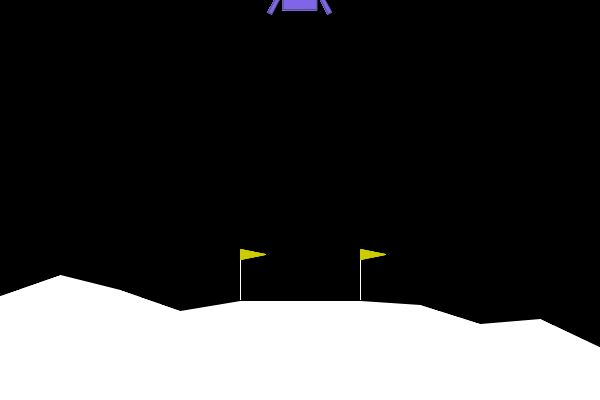

In [25]:
!pip install imageio[ffmpeg] -q

!PYTHONPATH=/content/td3_benchmark python /content/td3_benchmark/tests/test_buffer.py
!PYTHONPATH=/content/td3_benchmark python /content/td3_benchmark/train.py

from IPython.display import Image
Image(filename="results/lunarlander_agent.gif")

In [26]:
import shutil
from google.colab import files

shutil.make_archive("td3_lunarlander_results", "zip", root_dir="/content", base_dir="results")
shutil.make_archive("td3_benchmark_code", "zip", root_dir="/content", base_dir="td3_benchmark")

files.download("td3_lunarlander_results.zip")
files.download("td3_benchmark_code.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>